In [26]:
# Import Liabrary 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

In [27]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/subhashisrouth/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [28]:
# Load the pre-processed database
df = pd.read_csv("data/processed_reviews.csv")

In [29]:
df.head()

,college,review,rating,label,processed_review
0,sns college of technology - [snsct],"the annual fee for the course is 1,25,000. now...",6.0,0,annual fee course force pay fee early total bo...
1,bhagalpur college of engineering - [bce],the hostel life and social life in this colleg...,9.7,0,hostel life social life college enjoyable club...
2,shree lr tiwari college of engineering - [slrtce],i chose this course because i was interested i...,8.0,0,choose course interested mechanical engineerin...
3,iilm university,there is ignite fest in the university held on...,10.0,0,ignite f university hold campus availability j...
4,galgotias university - [gu],the civil department is very good in this coll...,6.2,0,civil department good college faculty member g...


In [30]:
# LABEL DISTRIBUTION

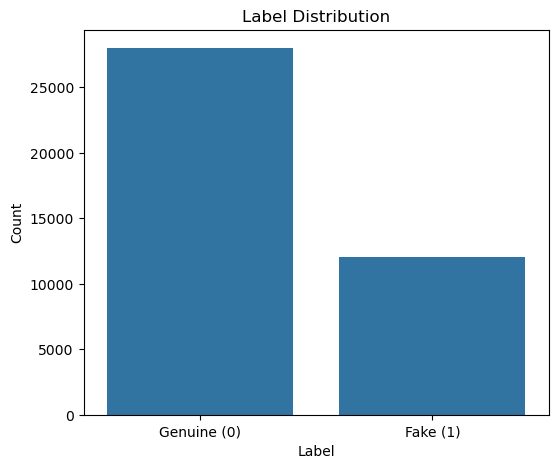

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(x='label', data=df)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks([0,1], ["Genuine (0)", "Fake (1)"])

plt.show()

In [32]:
# RATING DISTRIBUTION

/var/folders/7m/17k8m57x2zz1gnfmr86pkrdc0000gn/T/ipykernel_3958/671348422.py:16: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis='x', nbins=10)


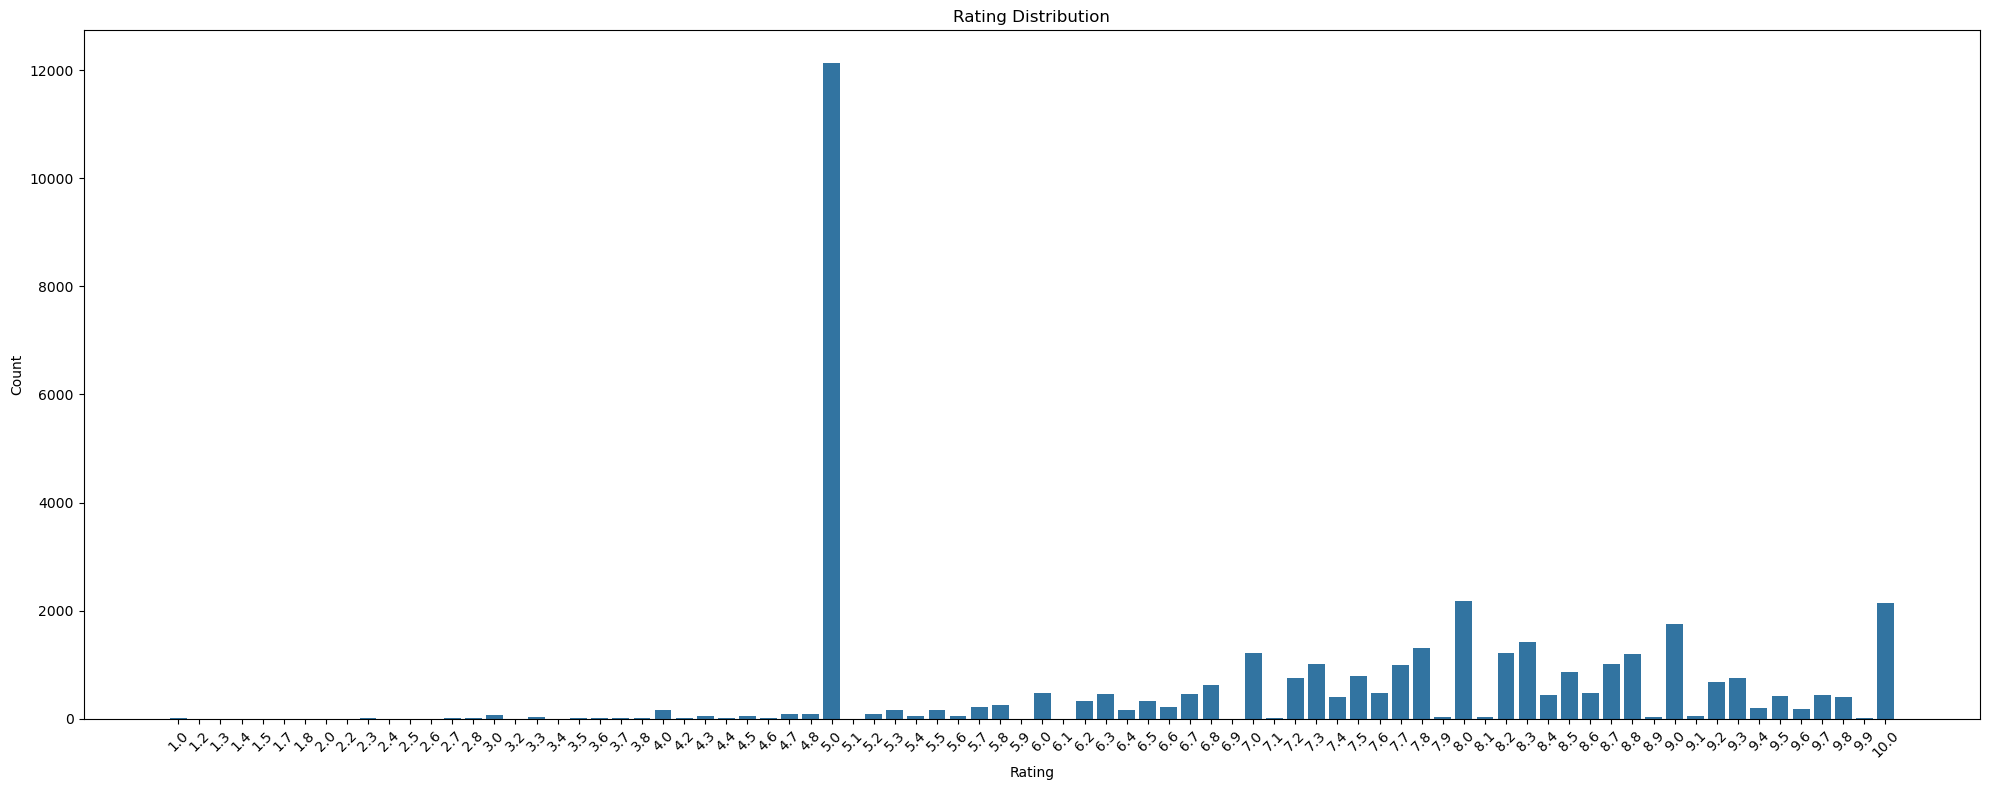

In [33]:
plt.figure(figsize=(20,8))

sns.countplot(
    x=df["rating"].round(1)
)

plt.title("Rating Distribution")

plt.xlabel("Rating")
plt.ylabel("Count")

# Rotate x labels
plt.xticks(rotation=45)

# Show fewer ticks
plt.locator_params(axis='x', nbins=10)

plt.tight_layout()

plt.show()

In [34]:
# REVIEW LENGTH DISTRIBUTION

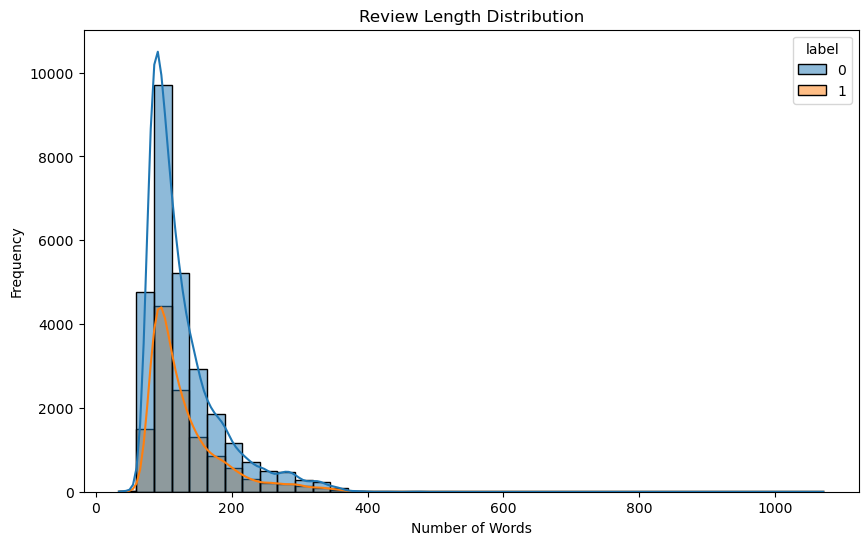

In [35]:
# Create review length column
df["review_length"] = df["review"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="review_length",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()


In [36]:
# WORD CLOUD - GENUINE REVIEWS

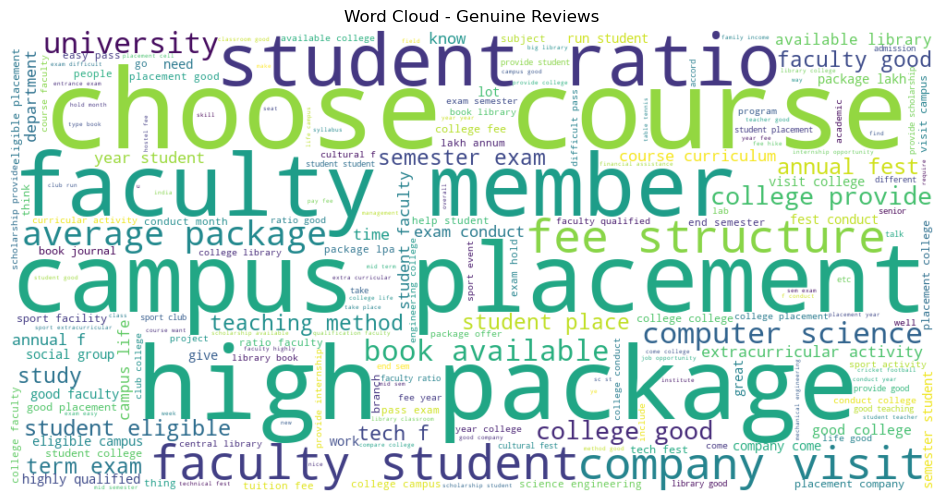

In [37]:
genuine_text = " ".join(
    df[df["label"] == 0]["processed_review"].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(genuine_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Word Cloud - Genuine Reviews")

plt.show()


In [38]:
# WORD CLOUD - FAKE REVIEWS

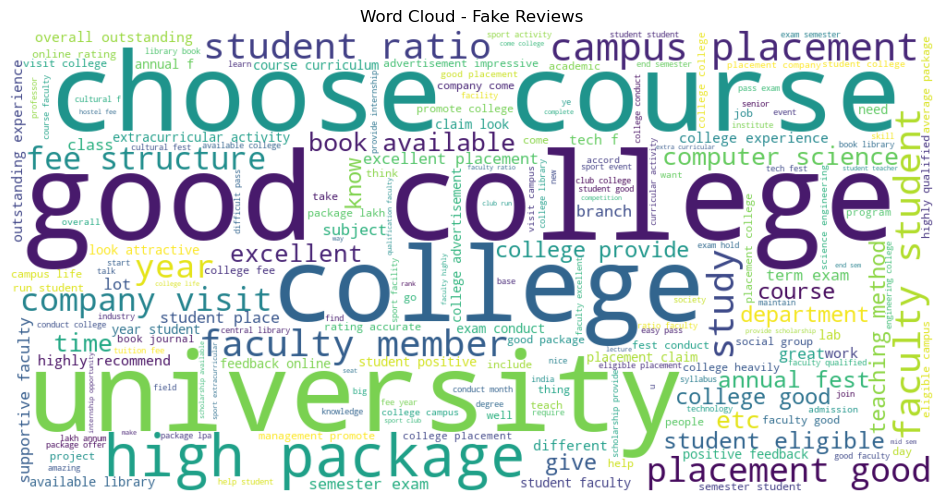

In [39]:
fake_text = " ".join(
    df[df["label"] == 1]["processed_review"].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Word Cloud - Fake Reviews")

plt.show()


In [40]:
# MOST COMMON WORDS - GENUINE REVIEWS

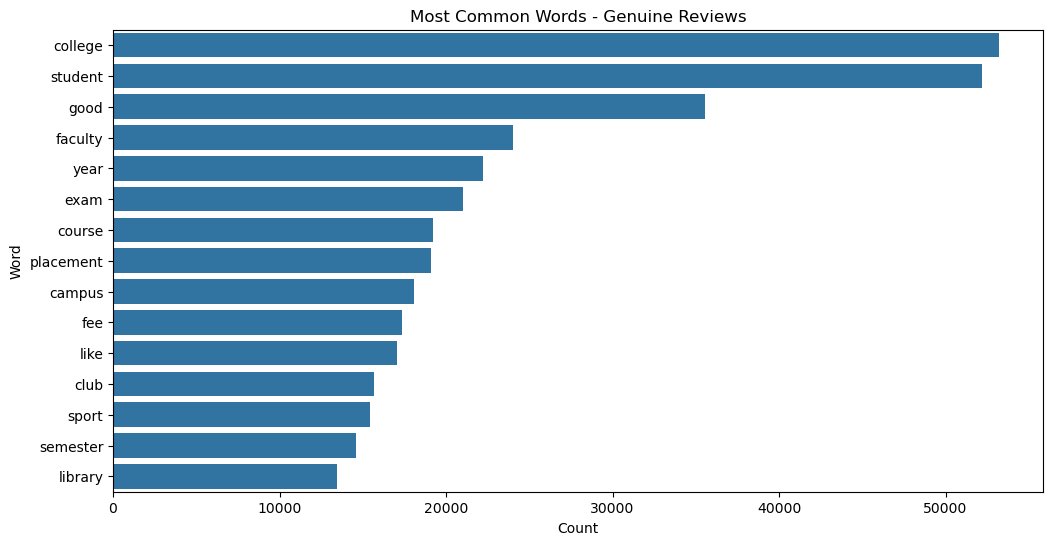

In [41]:
genuine_words = genuine_text.split()

genuine_common = Counter(genuine_words).most_common(15)

genuine_df = pd.DataFrame(
    genuine_common,
    columns=["Word", "Count"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Count",
    y="Word",
    data=genuine_df
)

plt.title("Most Common Words - Genuine Reviews")

plt.show()

In [42]:
# MOST COMMON WORDS - FAKE REVIEWS

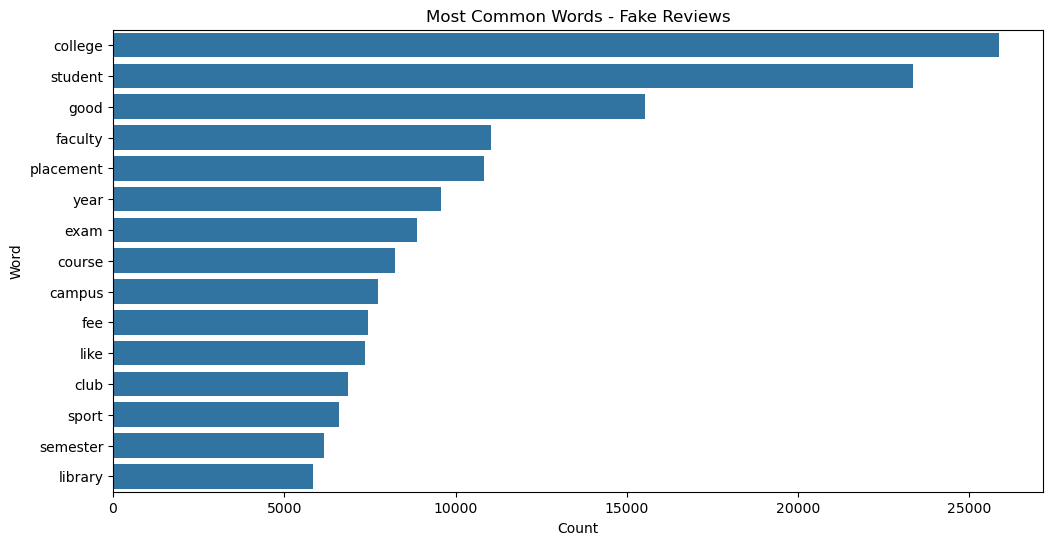

In [43]:
fake_words = fake_text.split()

fake_common = Counter(fake_words).most_common(15)

fake_df = pd.DataFrame(
    fake_common,
    columns=["Word", "Count"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Count",
    y="Word",
    data=fake_df
)

plt.title("Most Common Words - Fake Reviews")

plt.show()

In [44]:
# SENTIMENT VS RATING

In [45]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x=df["rating"].round(1),
    y="sentiment_score",
    data=df
)

plt.title("Sentiment Score vs Rating")

plt.xlabel("Rating")
plt.ylabel("Sentiment Score")

# Rotate labels
plt.xticks(rotation=45)

# Reduce clutter
plt.locator_params(axis='x', nbins=10)

plt.tight_layout()

plt.show()

ValueError: Could not interpret value `sentiment_score` for `y`. An entry with this name does not appear in `data`.

<Figure size 1500x600 with 0 Axes>

In [ ]:
# TOP COLLEGES WITH MOST REVIEWS

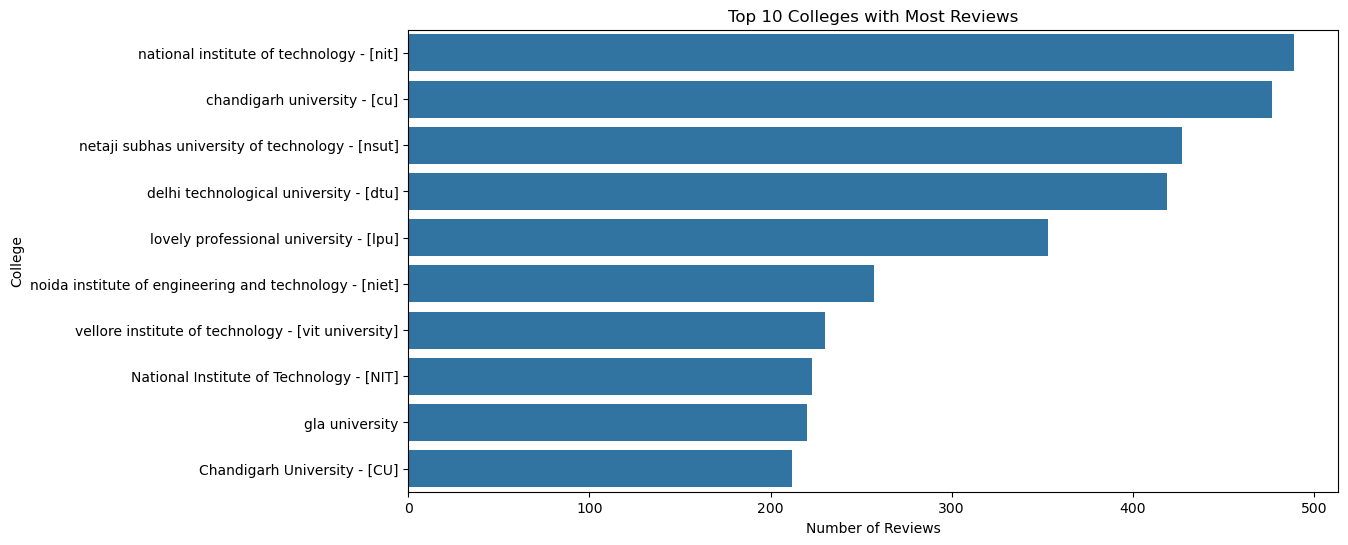

In [46]:
top_colleges = (
    df["college"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_colleges.values,
    y=top_colleges.index
)

plt.title("Top 10 Colleges with Most Reviews")

plt.xlabel("Number of Reviews")
plt.ylabel("College")

plt.show()

In [ ]:
# AVERAGE REVIEW LENGTH BY LABEL

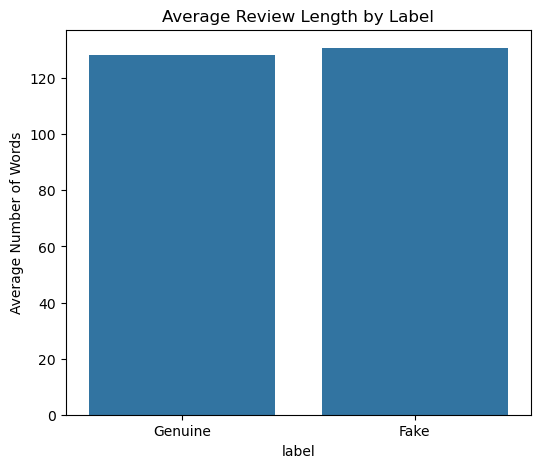

In [47]:
avg_length = (
    df.groupby("label")["review_length"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(
    x="label",
    y="review_length",
    data=avg_length
)

plt.xticks([0,1], ["Genuine", "Fake"])

plt.title("Average Review Length by Label")

plt.ylabel("Average Number of Words")

plt.show()